In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
results_path = "resnet_epoch1_layerwise_topology.csv"

df = pd.read_csv(results_path)

print(df)

   Block  Relative_Depth  H0_Descriptor  H1_Descriptor      Beta        R2  \
0      1             0.1     341.806491      16.119293  0.806206  0.997987   
1      2             0.2     498.197143      30.079620  0.801277  0.997994   
2      3             0.3     659.780214      46.413650  0.790878  0.996285   
3      4             0.4     771.639885      50.131021  0.785633  0.996279   
4      5             0.5     900.131325      62.157534  0.771107  0.996557   
5      6             0.6    1020.918543      71.173093  0.769210  0.996683   
6      7             0.7    1143.309399      79.656041  0.764712  0.997087   
7      8             0.8    1265.529693      83.540135  0.769779  0.997421   
8      9             0.9    1354.573822      84.172423  0.771726  0.997780   
9     10             1.0    1411.660249      84.444854  0.772153  0.997906   

      PHdim  
0  5.160108  
1  5.032132  
2  4.781891  
3  4.664893  
4  4.368858  
5  4.332940  
6  4.250103  
7  4.343648  
8  4.380707  
9

In [5]:
print("Number of blocks:", len(df))

print("H0 NaN:", df["H0_Descriptor"].isna().any())
print("H1 NaN:", df["H1_Descriptor"].isna().any())
print("PHdim NaN:", df["PHdim"].isna().any())

print("H0 Inf:", np.isinf(df["H0_Descriptor"]).any())
print("H1 Inf:", np.isinf(df["H1_Descriptor"]).any())
print("PHdim Inf:", np.isinf(df["PHdim"]).any())

Number of blocks: 10
H0 NaN: False
H1 NaN: False
PHdim NaN: False
H0 Inf: False
H1 Inf: False
PHdim Inf: False


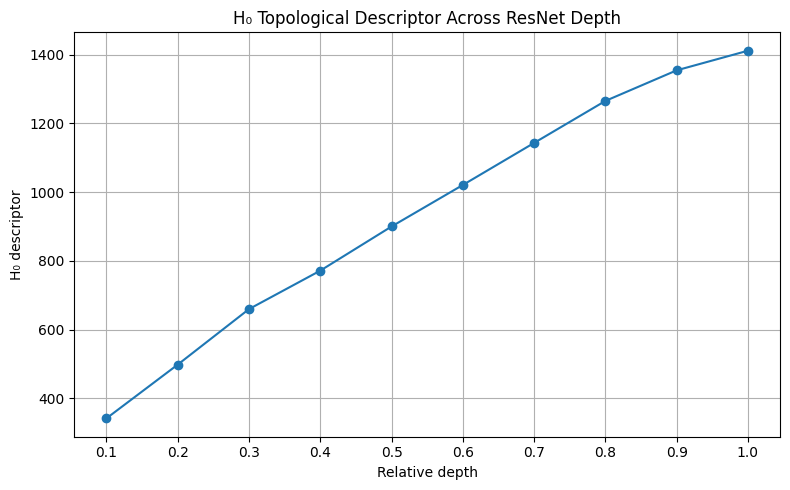

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["Relative_Depth"],
    df["H0_Descriptor"],
    marker="o"
)

plt.xlabel("Relative depth")
plt.ylabel("H₀ descriptor")
plt.title(
    "H₀ Topological Descriptor Across ResNet Depth"
)

plt.xticks(df["Relative_Depth"])

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "resnet_epoch1_H0_vs_depth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

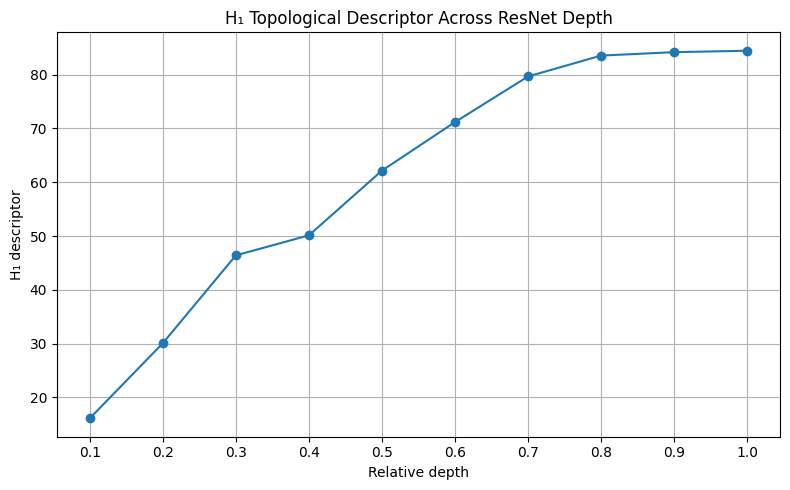

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["Relative_Depth"],
    df["H1_Descriptor"],
    marker="o"
)

plt.xlabel("Relative depth")
plt.ylabel("H₁ descriptor")
plt.title(
    "H₁ Topological Descriptor Across ResNet Depth"
)

plt.xticks(df["Relative_Depth"])

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "resnet_epoch1_H1_vs_depth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

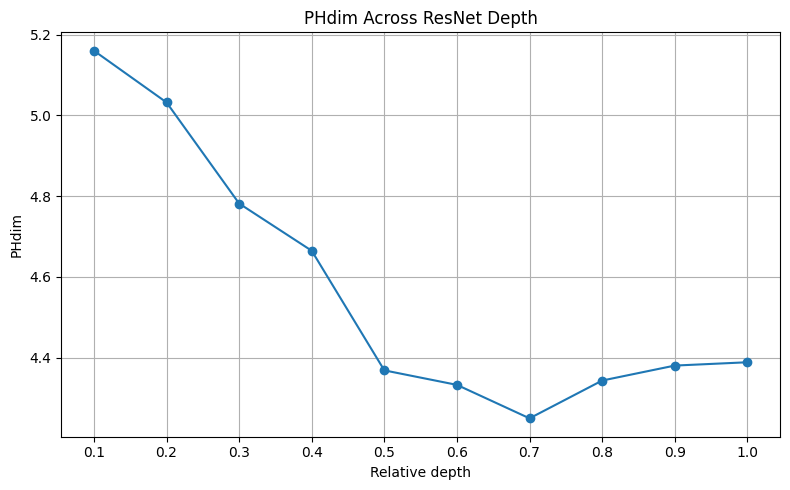

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["Relative_Depth"],
    df["PHdim"],
    marker="o"
)

plt.xlabel("Relative depth")
plt.ylabel("PHdim")
plt.title(
    "PHdim Across ResNet Depth"
)

plt.xticks(df["Relative_Depth"])

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "resnet_epoch1_PHdim_vs_depth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
h0_norm = (
    df["H0_Descriptor"]
    / df["H0_Descriptor"].iloc[0]
)

h1_norm = (
    df["H1_Descriptor"]
    / df["H1_Descriptor"].iloc[0]
)

phdim_norm = (
    df["PHdim"]
    / df["PHdim"].iloc[0]
)

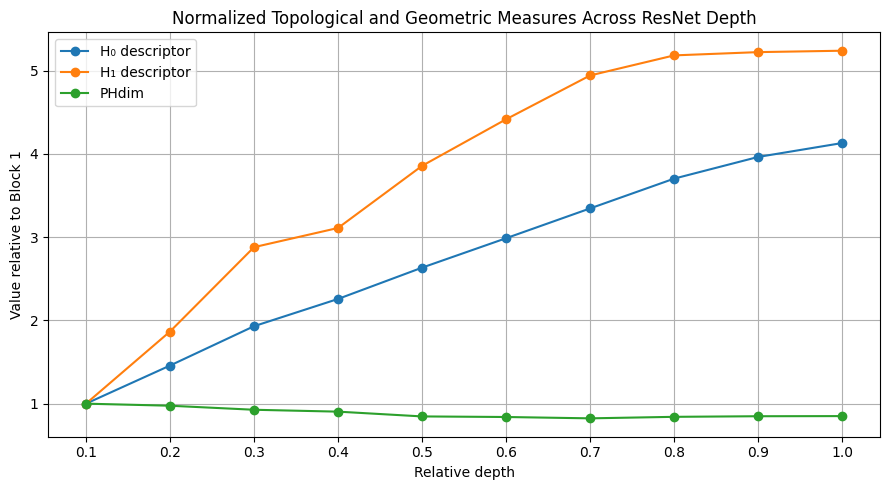

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    df["Relative_Depth"],
    h0_norm,
    marker="o",
    label="H₀ descriptor"
)

plt.plot(
    df["Relative_Depth"],
    h1_norm,
    marker="o",
    label="H₁ descriptor"
)

plt.plot(
    df["Relative_Depth"],
    phdim_norm,
    marker="o",
    label="PHdim"
)

plt.xlabel("Relative depth")
plt.ylabel("Value relative to Block 1")
plt.title(
    "Normalized Topological and Geometric Measures Across ResNet Depth"
)

plt.xticks(df["Relative_Depth"])

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "resnet_epoch1_normalized_topology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
report_table = df[
    [
        "Block",
        "Relative_Depth",
        "H0_Descriptor",
        "H1_Descriptor",
        "PHdim"
    ]
].copy()

report_table.columns = [
    "Block",
    "Relative Depth",
    "H0 Descriptor",
    "H1 Descriptor",
    "PHdim"
]

print(
    report_table.to_string(index=False)
)

 Block  Relative Depth  H0 Descriptor  H1 Descriptor    PHdim
     1             0.1     341.806491      16.119293 5.160108
     2             0.2     498.197143      30.079620 5.032132
     3             0.3     659.780214      46.413650 4.781891
     4             0.4     771.639885      50.131021 4.664893
     5             0.5     900.131325      62.157534 4.368858
     6             0.6    1020.918543      71.173093 4.332940
     7             0.7    1143.309399      79.656041 4.250103
     8             0.8    1265.529693      83.540135 4.343648
     9             0.9    1354.573822      84.172423 4.380707
    10             1.0    1411.660249      84.444854 4.388906


In [19]:
report_table_rounded = report_table.copy()

report_table_rounded[
    "Relative Depth"
] = report_table_rounded[
    "Relative Depth"
].round(1)

report_table_rounded[
    "H0 Descriptor"
] = report_table_rounded[
    "H0 Descriptor"
].round(4)

report_table_rounded[
    "H1 Descriptor"
] = report_table_rounded[
    "H1 Descriptor"
].round(4)

report_table_rounded[
    "PHdim"
] = report_table_rounded[
    "PHdim"
].round(4)

print(
    report_table_rounded.to_string(index=False)
)

 Block  Relative Depth  H0 Descriptor  H1 Descriptor  PHdim
     1             0.1       341.8065        16.1193 5.1601
     2             0.2       498.1971        30.0796 5.0321
     3             0.3       659.7802        46.4136 4.7819
     4             0.4       771.6399        50.1310 4.6649
     5             0.5       900.1313        62.1575 4.3689
     6             0.6      1020.9185        71.1731 4.3329
     7             0.7      1143.3094        79.6560 4.2501
     8             0.8      1265.5297        83.5401 4.3436
     9             0.9      1354.5738        84.1724 4.3807
    10             1.0      1411.6602        84.4449 4.3889


In [21]:
report_table_rounded.to_csv(
    "resnet_epoch1_layerwise_report_table.csv",
    index=False
)

print(
    "Saved: "
    "resnet_epoch1_layerwise_report_table.csv"
)

Saved: resnet_epoch1_layerwise_report_table.csv


In [23]:
df.to_csv(
    "resnet_epoch1_final_graph_data.csv",
    index=False
)

print(
    "Saved: "
    "resnet_epoch1_final_graph_data.csv"
)

Saved: resnet_epoch1_final_graph_data.csv
